### Data Wrangling: Customers

In [2]:
# Import Libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
from pathlib import Path

# Load dataset
data_path = Path("data/raw/customers.csv")
if not data_path.exists():
    data_path = Path("../data/raw/customers.csv")  

df = pd.read_csv(data_path)
df.head()
                               

,customer_id,name,age,gender,city,region,signup_date,membership_tier
0,C1000,Tarun Nair,20,Female,Surat,West,2020-08-16,Silver
1,C1001,Bhavna Nair,53,Male,Bhubaneswar,East,2020-02-02,Silver
2,C1002,Ananya Krishnan,33,Male,Ahmedabad,West,2022-01-03,Platinum
3,C1003,Vivek Shah,45,Male,Patna,East,2021-08-26,Silver
4,C1004,Aarav Gupta,46,Female,Chennai,South,2020-06-08,Silver


In [4]:
# Shape of dataset
df.shape

(200, 8)

In [5]:
# Data types
df.dtypes

customer_id          str
name                 str
age                int64
gender               str
city                 str
region               str
signup_date          str
membership_tier      str
dtype: object

In [7]:
# Statistical summary
df.describe(include='all')

,customer_id,name,age,gender,city,region,signup_date,membership_tier
count,200,200,200.000000,200,200,200,200,200
unique,200,172,NaN,2,16,4,176,3
top,C1000,Deepa Shah,NaN,Female,Patna,West,2022-01-03,Silver
freq,1,3,NaN,101,18,54,2,96
mean,NaN,NaN,38.275000,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,11.186378,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,48.000000,NaN,NaN,NaN,NaN,NaN


In [8]:
# Check for null values
df.isnull().sum()

customer_id        0
name               0
age                0
gender             0
city               0
region             0
signup_date        0
membership_tier    0
dtype: int64

In [9]:
# Check for duplicated values
df.duplicated().sum()

np.int64(0)

In [10]:
# Age validation
df[(df['age'] <= 0) | (df['age'] > 100)]

,customer_id,name,age,gender,city,region,signup_date,membership_tier


In [11]:
# Signup Date Validation
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')

df[df['signup_date'] > pd.Timestamp.today()]

,customer_id,name,age,gender,city,region,signup_date,membership_tier


In [12]:
# Gender consistency
df['gender'].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

In [13]:
# Membership tier consistency
df['membership_tier'].unique()

<ArrowStringArray>
['Silver', 'Platinum', 'Gold']
Length: 3, dtype: str

In [18]:
# City consistency
df['city'].unique()

<ArrowStringArray>
[      'Surat', 'Bhubaneswar',   'Ahmedabad',       'Patna',     'Chennai',
     'Kolkata',       'Kochi',   'Hyderabad',        'Pune',      'Jaipur',
       'Delhi',  'Chandigarh',      'Mumbai',    'Guwahati',     'Lucknow',
   'Bangalore']
Length: 16, dtype: str

In [26]:
# Membership tier distribution 
df['membership_tier'].value_counts(normalize=True) * 100

membership_tier
Silver      48.0
Gold        34.0
Platinum    18.0
Name: proportion, dtype: float64

In [29]:
# Signup Year
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['signup_year'] = df['signup_date'].dt.year
df['signup_year'].head() 

0    2020
1    2020
2    2022
3    2021
4    2020
Name: signup_year, dtype: int32

In [31]:
df['signup_year'].describe()

count     200.000000
mean     2020.740000
std         0.724586
min      2020.000000
25%      2020.000000
50%      2021.000000
75%      2021.000000
max      2022.000000
Name: signup_year, dtype: float64

In [35]:
# Membership vs age group
pd.crosstab(df['age_group'], df['membership_tier'])

membership_tier,Gold,Platinum,Silver
age_group,,,
18-25,16,3,21
26-35,15,7,20
36-50,26,18,39
50+,11,8,16


In [33]:
# Region wise customer distribution
df['region'].value_counts()

region
West     54
East     54
North    49
South    43
Name: count, dtype: int64

In [36]:
df['signup_date'].describe()

count                    200
mean     2021-03-16 22:48:00
min      2020-01-07 00:00:00
25%      2020-08-11 06:00:00
50%      2021-03-23 00:00:00
75%      2021-10-27 00:00:00
max      2022-06-18 00:00:00
Name: signup_date, dtype: object

In [39]:
# Tenure distribution
# Are customers new or long days?
reference_date = df['signup_date'].max()
df['tenure_days'] = (reference_date - df['signup_date']).dt.days
df['tenure_days'].describe()

# Customer tenure was calculated using the latest signup date in the dataset (2022-06-18) 
# As a reference to maintain consistency in analysis.

count    200.00000
mean     458.05000
std      261.65501
min        0.00000
25%      234.00000
50%      452.00000
75%      675.75000
max      893.00000
Name: tenure_days, dtype: float64

#### Insights

In [23]:
# Age group distribution
df['age_group'] = pd.cut(df['age'],
                        bins=[0,18,25,35,50,100],
                        labels=['Teen','18-25','26-35','36-50','50+'])

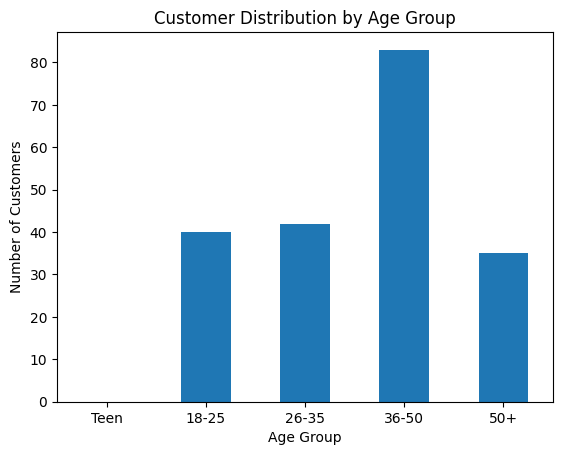

In [22]:
# Age group distribution
age_counts = df['age_group'].value_counts().sort_index()

plt.figure()
age_counts.plot(kind='bar')
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

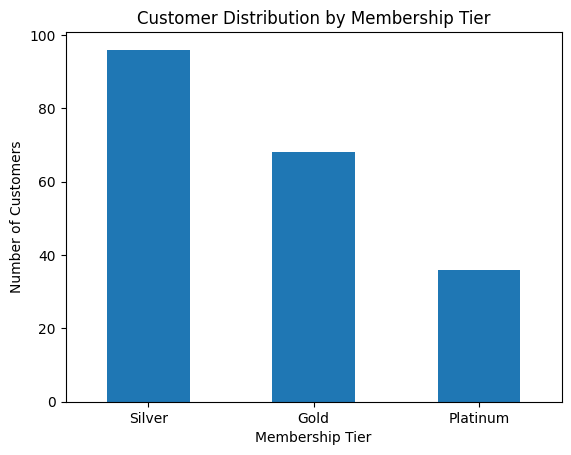

In [25]:
# Membership Tier distribution
tier_counts = df['membership_tier'].value_counts()

plt.figure()
tier_counts.plot(kind='bar')
plt.title('Customer Distribution by Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

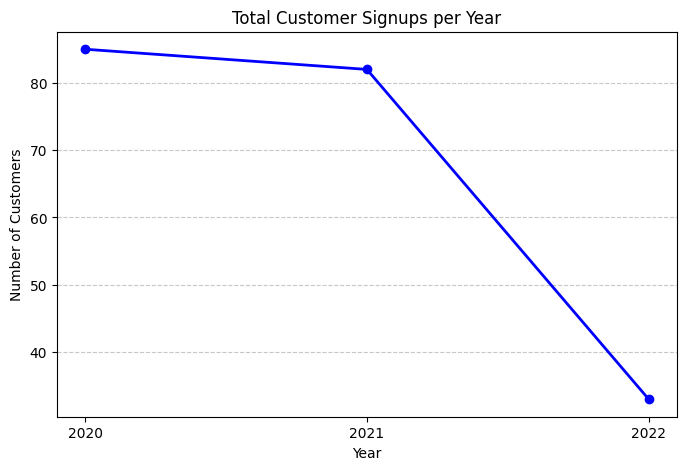

In [32]:
# Customer growth over time
growth = df.groupby('signup_year')['customer_id'].count()

plt.figure(figsize=(8, 5))
growth.plot(kind='line', marker='o', color='b', linewidth=2)
plt.xticks(growth.index) 
plt.title('Total Customer Signups per Year')
plt.xlabel('Year')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

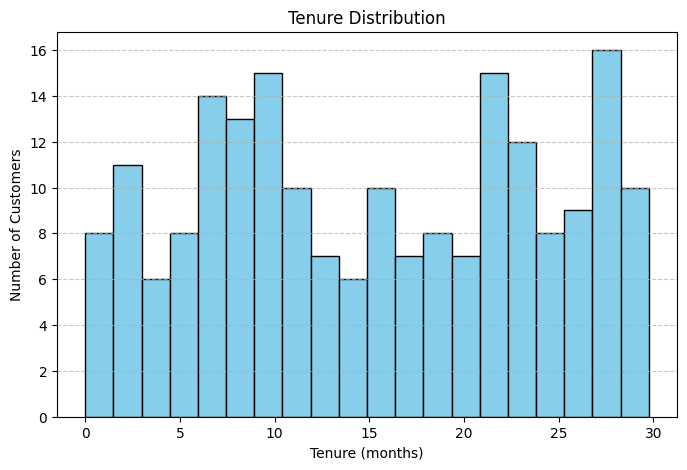

In [47]:
# Tenure distribution
df['tenure_months']=df['tenure_days']/30
plt.figure(figsize=(8, 5))
plt.hist(df['tenure_months'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()